In [17]:
import os
import sys
import warnings
import time
from datetime import timedelta
import numpy as np
import pandas as pd
import tensorflow as tf
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
from keras import backend as K

In [18]:
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')
sys.stderr = open(os.devnull, 'w')

In [19]:
img_height = 224
img_width = 224
batch_size = 4
data_dir = r"C:\Users\zxcv0\Desktop\LAB\second years\second semester\AT00CK36-3004 Implementing IoT Pipeline\Mira's lessons IoT Data Pipeline, common\Implementing-IoT-Pipeline\CSC_ML\data_dir"
num_classes = 2
epochs = 100

In [20]:
ml_start_time = time.time()
print("starting ML process...")


starting ML process...


In [21]:
image_paths = []
labels = []
class_names = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]

for label in class_names:
    class_dir = os.path.join(data_dir, label, label)
    if os.path.exists(class_dir):
        for image_file in os.listdir(class_dir):
            image_paths.append(os.path.join(class_dir, image_file))
            labels.append(class_names.index(label))

data = pd.DataFrame({'image_path': image_paths, 'label': labels})
data = data.sample(frac=1, random_state=123).reset_index(drop=True)

train_size = int(0.8 * len(data))
train_data = data[:train_size]
val_data = data[train_size:]

def create_dataset(data_frame):
    image_paths = data_frame['image_path'].values
    labels = data_frame['label'].values
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    def load_and_preprocess_image(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_jpeg(image, channels=3)
        image = tf.image.resize(image, [img_height, img_width])
        image = image / 255.0
        return image, label

    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.shuffle(buffer_size=len(data_frame)).batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset

train_ds = create_dataset(train_data)
val_ds = create_dataset(val_data)

In [22]:
data_load_time = time.time() - ml_start_time
print(f"Data loading completed, time taken: {timedelta(seconds=data_load_time)}")

Data loading completed, time taken: 0:00:00.125298


In [23]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(img_height, img_width, 3)),
    tf.keras.layers.Conv2D(16, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(num_classes)
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [ ]:
model_build_time = time.time() - ml_start_time
print(f"Model building completed, total time taken: {timedelta(seconds=model_build_time)}")

\Model building completed, total time taken: 0:00:00.293883


In [25]:
class ClearMemory(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        K.clear_session()
        gc.collect()

In [26]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6),
        ClearMemory()  
    ]
)

Epoch 1/25
325/325 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.9969 - loss: 0.0101 - val_accuracy: 1.0000 - val_loss: 3.0736e-07 - learning_rate: 0.0010
Epoch 2/25
325/325 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 1.0000 - loss: 1.4287e-07 - val_accuracy: 1.0000 - val_loss: 2.3731e-07 - learning_rate: 0.0010
Epoch 3/25
325/325 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 1.0000 - loss: 1.0417e-07 - val_accuracy: 1.0000 - val_loss: 1.8926e-07 - learning_rate: 0.0010
Epoch 4/25
325/325 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 1.0000 - loss: 7.8036e-08 - val_accuracy: 1.0000 - val_loss: 1.5112e-07 - learning_rate: 0.0010
Epoch 5/25
325/325 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 1.0000 - loss: 6.4006e-08 - val_accuracy: 1.0000 - val_loss: 1.4525e-07 - learning_rate: 2.0000e-04
Epoch 6/25
325/325 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 1.0000 - loss: 6.0796e-08 - val_accuracy: 1.0000 - val_loss: 1.3791e-07 - learning_rate: 2.0000e-04
Epoch 7/25
325/325 ━━━━━

In [27]:
training_time = time.time() - ml_start_time
print(f"Model training completed, time taken: {timedelta(seconds=training_time)}")


Model training completed, time taken: 0:05:03.684729


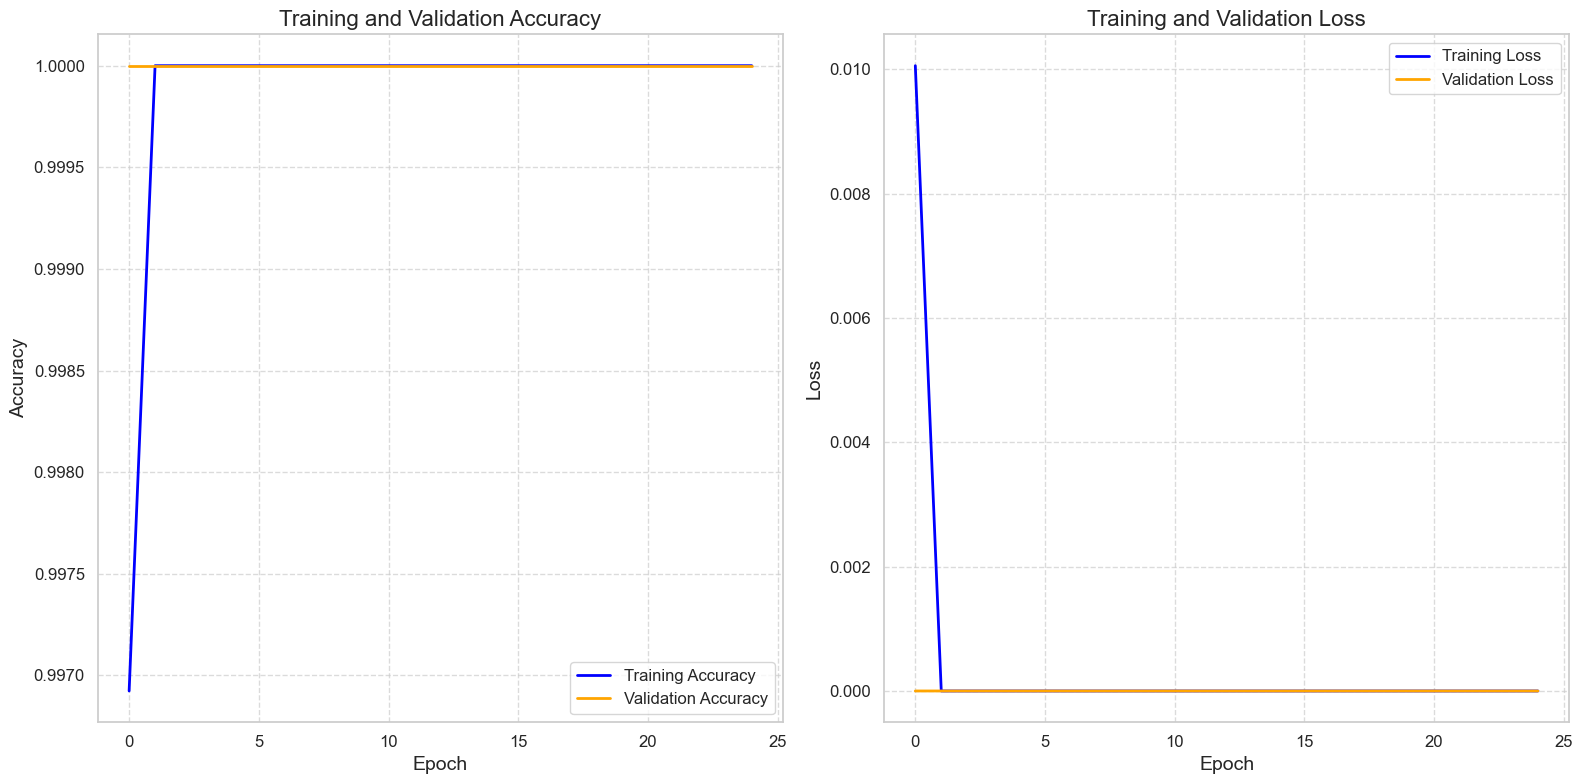

In [28]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
actual_epochs = len(history.history['accuracy'])
epochs_range = range(actual_epochs)

sns.set(style="whitegrid")
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Training and Validation Accuracy', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right', fontsize=12)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', linewidth=2)
plt.title('Training and Validation Loss', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()

In [29]:
model.save('model.keras')

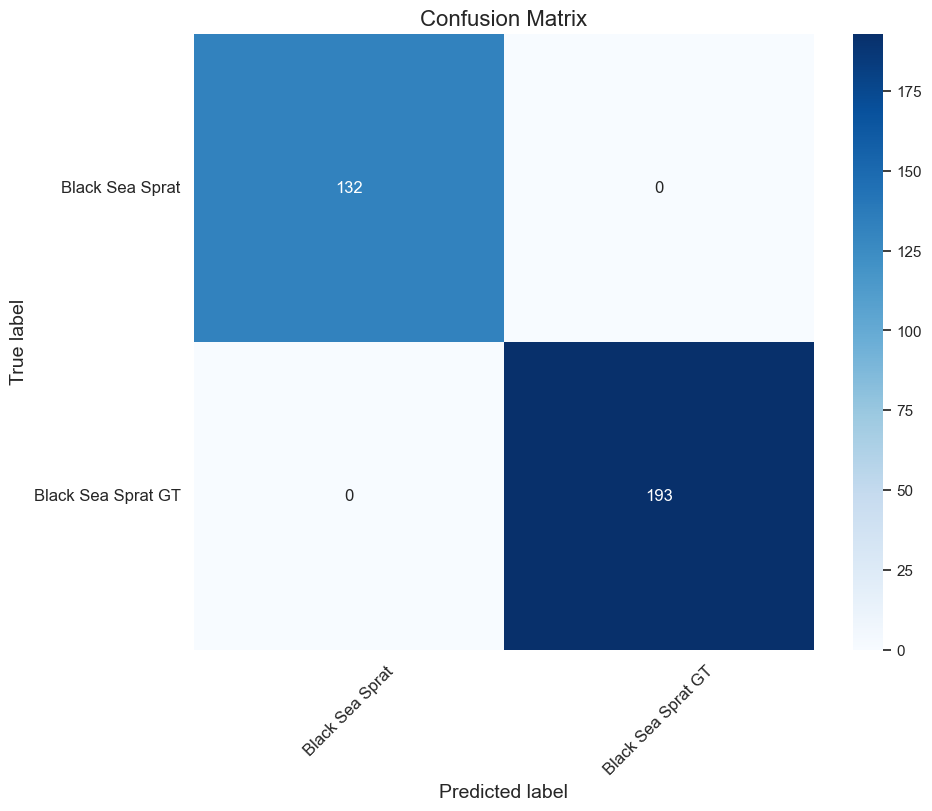

In [30]:
y_pred = []
y_true = []

for x_batch_val, y_batch_val in val_ds:
    preds = model.predict(x_batch_val, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(y_batch_val.numpy())

confusion_mtx = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('True label', fontsize=14)
plt.xlabel('Predicted label', fontsize=14)
plt.title('Confusion Matrix', fontsize=16)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.show()

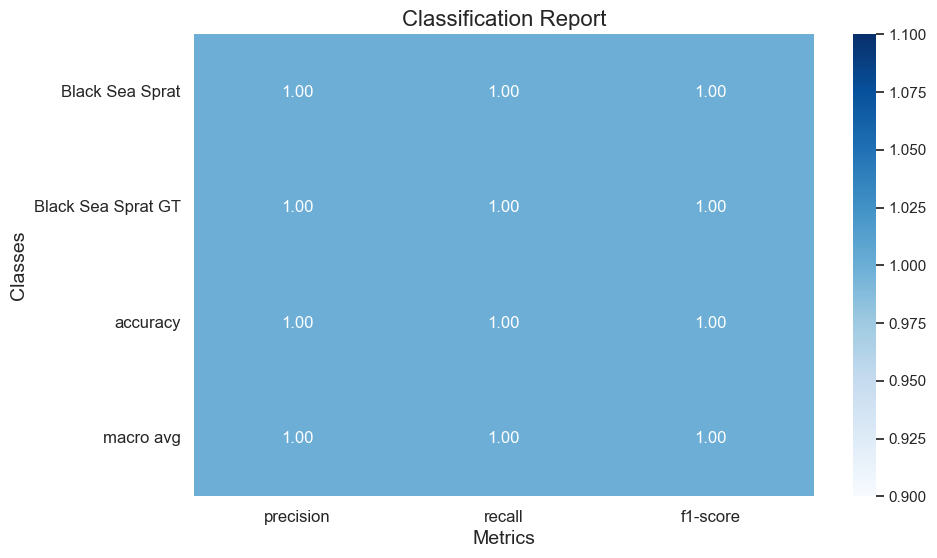

In [31]:
classification_rep = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

classification_df = pd.DataFrame(classification_rep).transpose()

plt.figure(figsize=(10, 6))
sns.heatmap(classification_df.iloc[:-1, :-1], annot=True, cmap='Blues', fmt='.2f')
plt.title('Classification Report', fontsize=16)
plt.ylabel('Classes', fontsize=14)
plt.xlabel('Metrics', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [32]:

ml_end_time = time.time()
total_seconds = ml_end_time - ml_start_time
total_time = timedelta(seconds=total_seconds)


print("ML process completed!")
print(f"Total time taken: {total_time} (total {total_seconds:.2f} seconds)")
print(f"Hours: {int(total_time.total_seconds() // 3600)}")
print(f"Minutes: {int((total_time.total_seconds() % 3600) // 60)}")
print(f"Seconds: {int(total_time.total_seconds() % 60)}")


ML process completed!
Total time taken: 0:05:12.788691 (total 312.79 seconds)
Hours: 0
Minutes: 5
Seconds: 12
